# Data Understanding and Preparation
Covers **Stage 1 + 2.1.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided (no change):* `config.py`. 
- *Provided to extend:* `src/data_prep.py` (function stubs). 
- *You build:* this notebook + the report.

Prereqs: `pip install -r requirements.txt`; extract the Kaggle casting dataset under `data/` (train/test → ok_front/def_front).

### 0. Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import config
from src import data_prep
# TODO: print config.CLASS_TO_IDX and config.POSITIVE_CLASS to confirm setup

print("Class mapping:", config.CLASS_TO_IDX)
print("Positive class:", config.POSITIVE_CLASS)
print("Positive class index:", config.POSITIVE_IDX)
print("Configured data directory:", config.DATA_DIR)

Class mapping: {'ok_front': 0, 'def_front': 1}
Positive class: def_front
Positive class index: 1
Configured data directory: C:\Users\naren\Documents\MLOps-Capstone\capstone\data


## **Stage 1.1 — Business & Data Understanding** <font color="red">[5 marks]</font>

- **1.1.1 — Business objective & justification [2]** — *to be done in the report*
- **1.1.2 — Success metric choice (recall/F1 on defects) [2]** — *to be done in the report*
- **1.1.3 — Dataset structure & class understanding [1]**

**Objective:** Understand the problem + dataset and name the right metric.

**Implement in:** this notebook (+ src/data_prep.find_data_root, list_images)

**Inputs → Outputs:** data/ images → counts + class distribution per split

**TODO:** locate the data root; count images per class per split; plot the distribution; state that defect = positive class and recall-on-defects (not accuracy) is the headline metric.

**Document here:** 1.1.1/1.1.2 in the report; 1.1.3 here (dataset structure).

In [5]:
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split
import pandas as pd
import matplotlib.pyplot as plt

root = data_prep.find_data_root()

records = []

for split in ("train", "test"):
    items = data_prep.list_images(root / split)

    for class_name, class_index in config.CLASS_TO_IDX.items():
        class_count = sum(
            label == class_index
            for _, label in items
        )

        records.append(
            {
                "split": split,
                "class_name": class_name,
                "class_index": class_index,
                "image_count": class_count,
            }
        )

class_distribution = pd.DataFrame(records)

print(f"Dataset root: {root}")
print(f"Total images: {class_distribution['image_count'].sum()}")
display(class_distribution)

Matplotlib is building the font cache; this may take a moment.


Dataset root: C:\Users\naren\Downloads\casting_data
Total images: 160


,split,class_name,class_index,image_count
0,train,ok_front,0,40
1,train,def_front,1,40
2,test,ok_front,0,40
3,test,def_front,1,40


In [ ]:
#Create and display distribution table for each split and class
distribution_table = (
    class_distribution
    .pivot(
        index="split",
        columns="class_name",
        values="image_count",
    )
    .reindex(columns=config.CLASSES)
    .fillna(0)
    .astype(int)
)

distribution_table["total"] = distribution_table.sum(axis=1)

display(distribution_table)

class_name,ok_front,def_front,total
split,,,
test,40,40,80
train,40,40,80


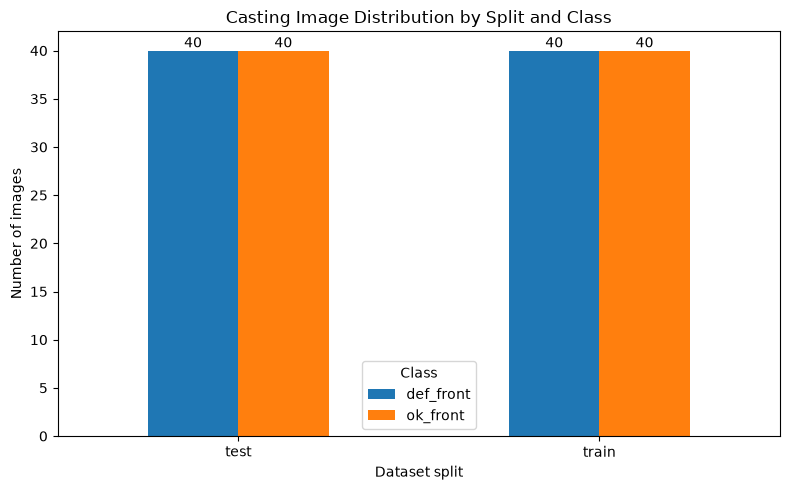

In [ ]:
#plot the distribution of images by split and class
plot_data = class_distribution.pivot(
    index="split",
    columns="class_name",
    values="image_count",
)

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Casting Image Distribution by Split and Class")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Class")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains two classes:

- `ok_front`, mapped to class label 0, represents acceptable castings.
- `def_front`, mapped to class label 1, represents defective castings.

The defective class is deliberately treated as the positive class because the
main operational objective is to detect defective castings before they continue
through production.

The current development dataset contains 160 images. The supplied training
directory contains 80 images and the supplied test directory contains 80 images.
Each split contains 40 acceptable and 40 defective images, resulting in an even
50:50 class distribution.

The balanced distribution means that class imbalance is not present in this
development subset. However, accuracy will still not be used as the primary
selection metric because a false negative represents a defective casting that
the model incorrectly accepts. Recall on the defect class therefore remains the
headline metric.

The current dataset is a small development subset rather than the approximately
7,348-image dataset described in the project specification. The implementation
is therefore designed to work without changes when the complete dataset is used.

## **Stage 1.2 — Data Quality Validation** <font color="red">[5 marks]</font>

- **1.2.1 — Corrupt-file & image-dimension checks [2]**
- **1.2.2 — Duplicate detection (hashing) — leakage guard [2]**
- **1.2.3 — Class distribution + pass/fail report [1]**

**Objective:** Programmatically validate image quality before any split.

**Implement in:** src/data_prep.validate_quality

**Inputs → Outputs:** data root → a pass/fail report dict (corrupt, duplicates, dimensions, distribution)

**TODO:** check missing/corrupt files (Image.verify) and dimensions (1.2.1); detect DUPLICATE images via md5/hash (1.2.2); quantify class balance + print a pass/fail report (1.2.3); expect ~7,348 images, ~64 duplicates.

**Document here:** the quality report + why duplicate detection prevents train/test leakage.

In [9]:
# TODO 1.2.1-1.2.3: qc = data_prep.validate_quality(root); print(qc['total_images'], qc['passed'])
import json

root = data_prep.find_data_root()
quality_report = data_prep.validate_quality(root)

quality_report_path = (
    config.ARTIFACT_DIR / "data_quality_report.json"
)

quality_report_path.write_text(
    json.dumps(quality_report, indent=2),
    encoding="utf-8",
)

print(f"Quality report saved to: {quality_report_path}")
print(f"Overall quality status: "
      f"{'PASS' if quality_report['passed'] else 'FAIL'}")

Quality report saved to: C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\data_quality_report.json
Overall quality status: FAIL


In [ ]:
# Display the result of corrupt files and invalid dimensions in a tabular format using pandas DataFrame. If there are no corrupt files or invalid dimensions, print a PASS message.
if quality_report["corrupt_files"]:
    display(pd.DataFrame(quality_report["corrupt_files"]))
else:
    print("PASS: No corrupt or unreadable image files were detected.")

if quality_report["invalid_dimensions"]:
    display(pd.DataFrame(quality_report["invalid_dimensions"]))
else:
    print("PASS: All readable images have dimensions 300 x 300 pixels.")

PASS: No corrupt or unreadable image files were detected.
PASS: All readable images have dimensions 300 x 300 pixels.


In [ ]:
# Display the result of duplicate images in a tabular format using pandas DataFrame.
duplicate_summary = {
    "duplicate_group_count":
        quality_report["duplicates"]["duplicate_group_count"],
    "duplicate_file_count":
        quality_report["duplicates"]["duplicate_file_count"],
    "excess_duplicate_count":
        quality_report["duplicates"]["excess_duplicate_count"],
    "cross_split_group_count":
        quality_report["duplicates"]["cross_split_group_count"],
    "cross_class_group_count":
        quality_report["duplicates"]["cross_class_group_count"],
}

display(pd.DataFrame([duplicate_summary]))

,duplicate_group_count,duplicate_file_count,excess_duplicate_count,cross_split_group_count,cross_class_group_count
0,22,44,22,22,0


In [19]:
# Display the details of duplicate images in a tabular format using pandas DataFrame.
duplicate_rows = []

for group in quality_report["duplicates"]["groups"]:
    duplicate_rows.append(
        {
            "hash": group["md5"][:12],
            "file_count": group["file_count"],
            "cross_split": group["cross_split"],
            "cross_class": group["cross_class"],
            "files": " | ".join(group["files"]),
        }
    )

duplicate_examples = pd.DataFrame(duplicate_rows)

if duplicate_examples.empty:
    print("No exact duplicate images were detected.")
else:
    display(duplicate_examples.head(10))

,hash,file_count,cross_split,cross_class,files
0,033f2c3cd5e4,2,True,False,test/ok_front/cast_ok_0_1022.jpeg | train/ok_f...
1,05d1192be741,2,True,False,test/ok_front/cast_ok_0_1095.jpeg | train/ok_f...
2,0ef55c5885f5,2,True,False,test/ok_front/cast_ok_0_1003.jpeg | train/ok_f...
3,22ec0f424b08,2,True,False,test/ok_front/cast_ok_0_1066.jpeg | train/ok_f...
4,329e01de9631,2,True,False,test/ok_front/cast_ok_0_1096.jpeg | train/ok_f...
5,33a0b23b1e90,2,True,False,test/ok_front/cast_ok_0_1069.jpeg | train/ok_f...
6,355f9117005a,2,True,False,test/ok_front/cast_ok_0_1040.jpeg | train/ok_f...
7,37b99d4b316e,2,True,False,test/ok_front/cast_ok_0_1077.jpeg | train/ok_f...
8,3b20a1bcf173,2,True,False,test/ok_front/cast_ok_0_1028.jpeg | train/ok_f...
9,4d0e3e62ae89,2,True,False,test/ok_front/cast_ok_0_1019.jpeg | train/ok_f...


In [ ]:
# Display the class distribution for each split in a tabular format using pandas DataFrame.
class_rows = []

for split, class_results in (
    quality_report["class_distribution"].items()
):
    for class_name, result in class_results.items():
        class_rows.append(
            {
                "split": split,
                "class_name": class_name,
                "class_index":
                    config.CLASS_TO_IDX[class_name],
                "count": result["count"],
                "percentage": result["percentage"],
            }
        )

quality_class_distribution = pd.DataFrame(class_rows)

display(quality_class_distribution)

,split,class_name,class_index,count,percentage
0,train,ok_front,0,40,50.0
1,train,def_front,1,40,50.0
2,test,ok_front,0,40,50.0
3,test,def_front,1,40,50.0


In [ ]:
# Display the results of quality checks in a tabular format using pandas DataFrame.
quality_check_table = pd.DataFrame(
    [
        {
            "check": check_name,
            "status": result["status"],
            "issue_count": result["issue_count"],
        }
        for check_name, result
        in quality_report["checks"].items()
    ]
)

display(quality_check_table)

,check,status,issue_count
0,required_directories,PASS,0
1,corrupt_files,PASS,0
2,image_dimensions,PASS,0
3,class_distribution,PASS,0
4,exact_duplicates,FAIL,22
5,cross_split_leakage,FAIL,22
6,class_label_consistency,PASS,0


### Data-quality interpretation

A programmatic data-quality assessment was completed before creating the final
model-development partitions. The validation covered directory structure,
class presence, image readability, expected image dimensions, exact duplicate
detection and cross-split leakage.

The dataset contains 160 images, with 40 acceptable and 40 defective images in
each of the supplied train and test directories. No corrupt or unreadable files
were detected, and all images have the expected dimensions of 300 × 300 pixels.

Exact-content hashing identified 22 duplicate groups. All 22 duplicate groups
cross the supplied train/test boundary. This represents data leakage because
identical visual information could be available during both model training and
final evaluation. Performance calculated using the original supplied split
could therefore overestimate the model's ability to generalise to unseen
castings.

No duplicate groups crossed class boundaries, indicating that identical images
were not assigned conflicting labels.

The overall data-quality result is FAIL because the supplied train/test
structure is not leakage-safe. The original partitions will not be used
unchanged. During dataset versioning, duplicate images will be grouped by their
content hash so that identical image content cannot appear in more than one
final partition.

## **Stage 1.3 — Dataset Versioning & Metadata** <font color="red">[5 marks]</font>

- **1.3.1 — Reproducible, stratified train/val/test split [3]**
- **1.3.2 — Split snapshot + metadata.json (versioning) [2]**

**Objective:** Create reproducible, versioned splits.

**Implement in:** src/data_prep.build_splits

**Inputs → Outputs:** data root + version id → train/val/test file lists + metadata.json

**TODO:** make a STRATIFIED train/val/test split (seed 42) (1.3.1); snapshot the file lists + write metadata.json (version id, date, class defs, split sizes, seed) (1.3.2).

**Document here:** the split sizes + the metadata record.

In [ ]:
# TODO 1.3.1-1.3.2: meta = data_prep.build_splits(root, 'v1'); print(meta['split_info'])


## **Stage 1.4 — EDA & Methodology Design** <font color="red">[5 marks]</font>

- **1.4.1 — Image-characteristic EDA [3]** — *to be done in this notebook and the report*
- **1.4.2 — End-to-end MLOps workflow design [2]** — *to be done in the report*

**Objective:** Explore image characteristics that motivate preprocessing + drift features.

**Implement in:** this notebook (+ src/data_prep.image_features)

**Inputs → Outputs:** sample images → a feature table (brightness/contrast/edge/sharpness/dark-ratio) by class

**TODO:** show a sample grid (OK vs Defective) + per-class feature means (1.4.1); in the report, design the end-to-end MLOps workflow (1.4.2).

**Document here:** an interpretation cell (1.4.1) + the workflow design in the report (1.4.2).

In [ ]:
# TODO 1.4.1: sample-image grid; per-class image_features means


## **Stage 2.1 — Preprocessing & Augmentation** <font color="red">[6 marks]</font>

- **2.1.1 — Convert greyscale image to 3-channel RGB, resize 224, ImageNet normalise [3]**
- **2.1.2 — Train-only augmentation (val/test none) [3]**

**Objective:** Build transforms that match the pretrained ResNet18 backbone.

**Implement in:** src/data_prep.get_transforms

**Inputs → Outputs:** a PIL image → a (3,224,224) normalised tensor; train transform adds augmentation

**TODO:** Convert greyscale image to 3-channel RGB, Resize 224, ImageNet normalise (2.1.1); train-time augmentation (flip/rotation/translate/colour jitter) with val/test NO augmentation (2.1.2).

**Document here:** a before/after visualisation of the transforms.

In [ ]:
# TODO 2.1.1-2.1.2: tf=data_prep.get_transforms(train=True); verify a sample tensor is (3,224,224)


---
**Outputs feed Stage 2.2+** in `Model_Development_and_Tracking.ipynb` (the versioned splits + transforms are reused to train the model).